In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Introduction 

This machine learning project is based on the dataset indian_bikes, which contains information about different motorcycle brands and models in India. The dataset includes bike specifications, pricing details, GST values, mileage, top speed, fuel tank capacity, and customer behaviour factors.

The main objective of this project is to analyze the relationship between bike features and customer purchasing behaviour using machine learning techniques. 



### Data Description 

##### Dataset Features

| Column Name        | Description                                      |
|--------------------|--------------------------------------------------|
| brand              | Manufacturer company of the bike                 |
| model              | Name of the bike model                           |
| cc                 | Engine capacity in cubic centimeters             |
| segment            | Category of bike such as budget, mid, or premium |
|year                | Manufacturing or launch year                     |
|speedometer_type    | Type of speedometer used in the bike             |
|top_speed_kmh       | Maximum speed of the bike in km/h                |
|mileage_kmpl        | Fuel efficiency in kilometers per liter          |
|fuel_tank_litersFuel| tank capacity in liters                          |
|factory_price_inr   | Manufacturing price in Indian Rupees             |
|gst_rate_pct        |GST percentage applied to the bike                |
|gst_amount_inr      |GST amount in Indian Rupees                       |
|ex_showroom_inr     |Ex-showroom price of the bike                     |
|on_road_price_inr   |Final on-road price of the bike                   |
|overall_score       |Overall performance or rating score               |
|price_increase_scenario_pct|Percentage increase in bike price          |
|buyer_behaviour      | Customer reaction to price increase             |
|price_sensitivity    |Customer sensitivity towards price changes       |



In [50]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\indian_bikes_dataset_1000.csv")
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium


In [102]:
df.brand.unique()

array([2, 0, 1, 4, 6, 7, 3, 5])

### Data Inspection

1) Viewed first rows using "df.head"

2) Viewed last rows using "df.tail"

3) Checked shape using "df.shape"

4) Checked how many columns using "df.columns"

5) summary of the data structure "df.info()"

6) Null values using "df.isnull().sum()"

7) viewed dtypes "df.dtypes"

In [51]:
df.head()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
0,Honda,Hornet 2.0,184,mid,2020,Digital,137,43.8,10.1,100781,28.0,28219,129000,147604,70,9.3,Will likely switch brand,High
1,Bajaj,Pulsar N250,249,mid,2024,Digital,157,33.2,14.9,123438,28.0,34562,158000,185890,71,4.1,Might reconsider,Medium
2,Hero,Splendor Plus,97,budget,2020,Analog,95,64.2,8.7,60156,28.0,16844,77000,89751,57,2.3,Might reconsider,Medium
3,Royal Enfield,Thunderbird 350X,346,premium,2025,Semi-Digital,152,29.1,17.3,146875,28.0,41125,188000,221689,67,8.7,Will likely switch brand,High
4,Royal Enfield,Scram 411,411,premium,2023,Semi-Digital,165,23.4,14.9,166412,31.0,51588,218000,251257,73,13.1,Will definitely switch,Very High


In [52]:
df.tail()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,buyer_behaviour,price_sensitivity
995,Yamaha,R3,321,premium,2020,Digital,144,33.6,15.0,360938,28.0,101062,462000,530814,73,7.0,Will likely switch brand,High
996,Hero,Super Splendor,125,budget,2022,Semi-Digital,117,53.5,12.4,70312,28.0,19688,90000,107247,59,13.5,Will definitely switch,Very High
997,Bajaj,Platina 110 H-Gear,115,budget,2024,Semi-Digital,111,50.2,10.8,63281,28.0,17719,81000,97000,61,2.9,Might reconsider,Medium
998,TVS,Ronin,225,mid,2024,Digital,165,29.6,16.1,120312,28.0,33688,154000,180601,70,2.3,Might reconsider,Medium
999,Royal Enfield,Meteor 350,349,premium,2024,Semi-Digital,153,31.4,13.2,164062,28.0,45938,210000,243807,72,7.5,Will likely switch brand,High


In [53]:
df.shape

(1000, 18)

In [54]:
df.columns

Index(['brand', 'model', 'cc', 'segment', 'year', 'speedometer_type',
       'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct', 'buyer_behaviour', 'price_sensitivity'],
      dtype='object')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   brand                        1000 non-null   object 
 1   model                        1000 non-null   object 
 2   cc                           1000 non-null   int64  
 3   segment                      1000 non-null   object 
 4   year                         1000 non-null   int64  
 5   speedometer_type             1000 non-null   object 
 6   top_speed_kmh                1000 non-null   int64  
 7   mileage_kmpl                 1000 non-null   float64
 8   fuel_tank_liters             1000 non-null   float64
 9   factory_price_inr            1000 non-null   int64  
 10  gst_rate_pct                 1000 non-null   float64
 11  gst_amount_inr               1000 non-null   int64  
 12  ex_showroom_inr              1000 non-null   int64  
 13  on_road_price_inr  

In [56]:
df.isnull().sum()

brand                          0
model                          0
cc                             0
segment                        0
year                           0
speedometer_type               0
top_speed_kmh                  0
mileage_kmpl                   0
fuel_tank_liters               0
factory_price_inr              0
gst_rate_pct                   0
gst_amount_inr                 0
ex_showroom_inr                0
on_road_price_inr              0
overall_score                  0
price_increase_scenario_pct    0
buyer_behaviour                0
price_sensitivity              0
dtype: int64

The **Indian_Bike Dataset** has no missing values,that was clean.

 # Exploratory Data Analysis

 Exploratory Data Analysis (EDA) was performed on the dataset indian_bikes_dataset to understand the structure, trends, and relationships between bike specifications, pricing details, and customer behaviour.


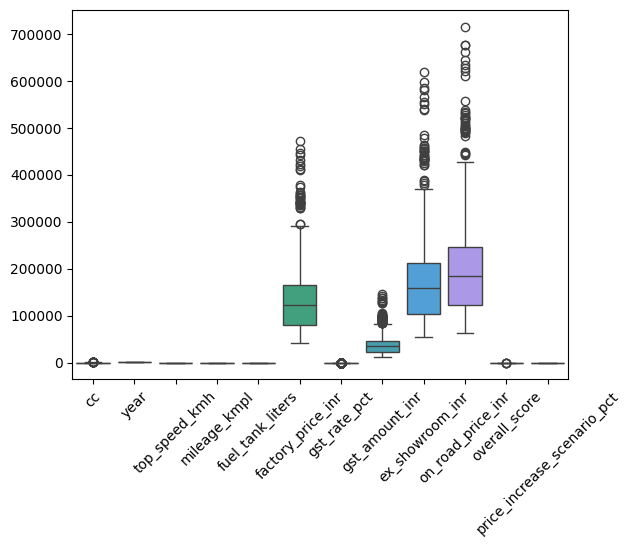

In [57]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

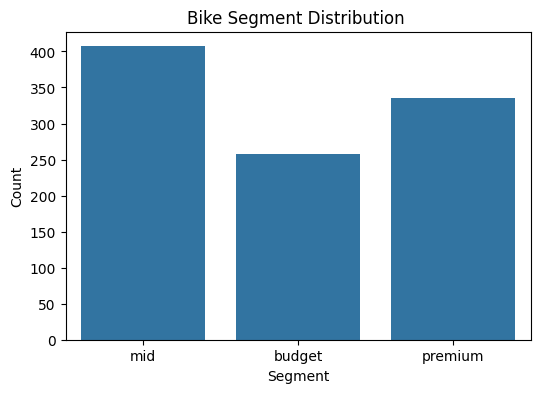

In [58]:
# bike segment

plt.figure(figsize=(6,4))
sns.countplot(x='segment',data=df)
plt.title("Bike Segment Distribution ")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

The count plot shows the distribution of motorcycles across different bike segments in the dataset.

1) Mid segment bikes have the highest count 410.
2) The premium segment is the second highest, containing approximately 335 bikes.
3) Budget bikes has the lowest count, with about 260 bikes.
4) This indicates that mid-range motorcycles are more popular and widely available in the Indian bike market.

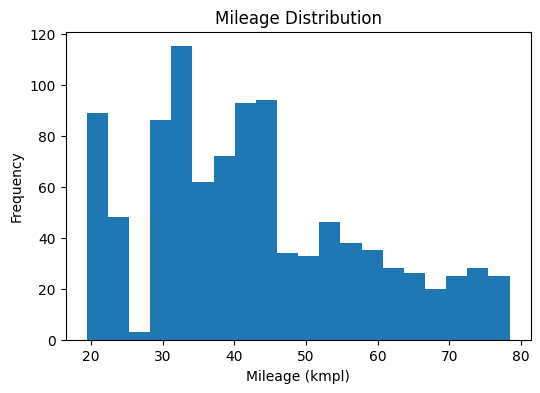

In [59]:
# Milege

plt.figure(figsize=(6,4))
plt.hist(df['mileage_kmpl'], bins=20)
plt.title("Mileage Distribution")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Frequency")
plt.show()

The histogram represents the distribution of bike mileage (kmpl) in the dataset.

1) The mileage values range from around 20 kmpl to 78 kmpl.
2) Most bikes are concentrated between 30 kmpl and 45 kmpl, showing this is the most common mileage range.
3) There are fewer bikes with very high mileage above 60 kmpl.
4) The distribution is slightly spread out, indicating variation in fuel efficiency among different bike models.



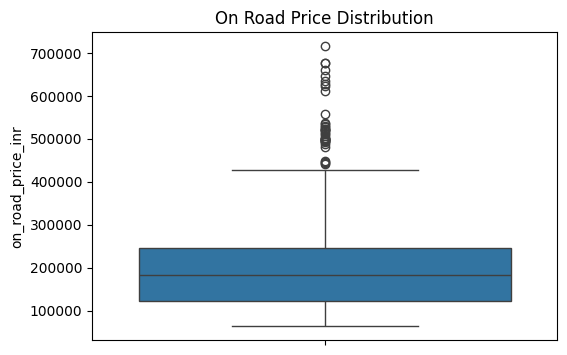

In [60]:
# on road price 

plt.figure(figsize=(6,4))
sns.boxplot(y='on_road_price_inr', data=df)
plt.title("On Road Price Distribution")
plt.show()

The box plot shows that:
1) Median on-road price is around ₹180,000.
2) Most bike prices range between ₹120,000 and ₹250,000.
3) Minimum price is approximately ₹65,000.
4) Several high-price outliers are present above ₹450,000.
5) Maximum on-road price reaches around ₹720,000.

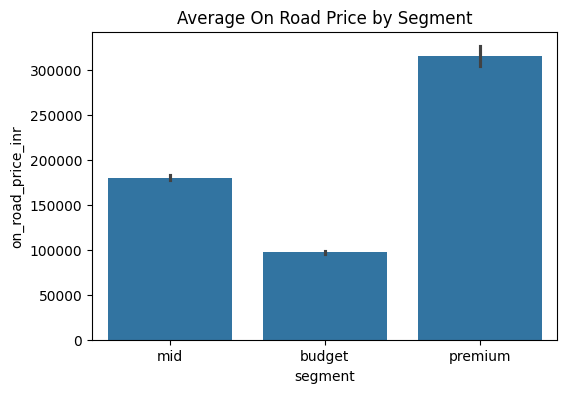

In [61]:
#  Average Price by Segment

plt.figure(figsize=(6,4))
sns.barplot(x='segment', y='on_road_price_inr', data=df)
plt.title("Average On Road Price by Segment")
plt.show()

The bar plot indicate :
1) Premium segment has the highest average on-road price at around ₹315,000.
2) Mid segment average price is approximately ₹180,000.
3) Budget segment has the lowest average price near ₹100,000.
4) Clear price difference exists between all three bike segments.
5) Premium bikes are significantly more expensive than budget and mid-range bikes.

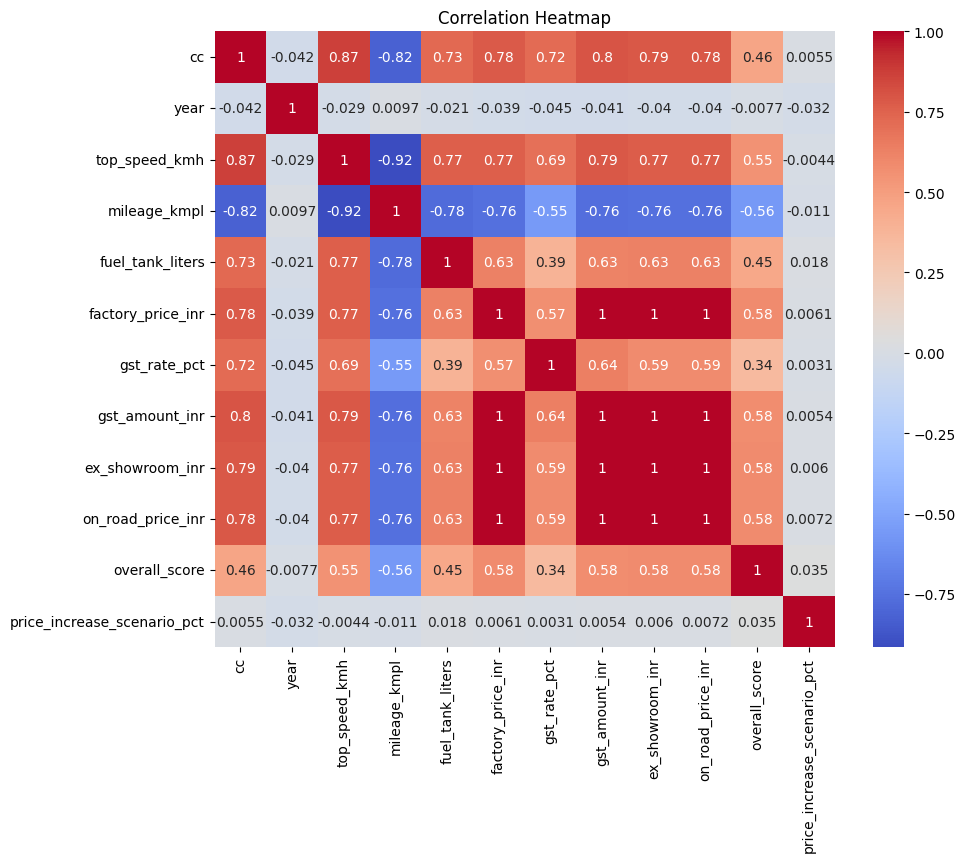

In [62]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 Correlation Heatmap is shows that:

 1) CC and Top Speed have a strong positive correlation (0.87), meaning bikes with higher engine capacity usually have higher top speed.
2) Mileage and Top Speed show a strong negative correlation (-0.92), indicating that faster bikes tend to have lower mileage.
3) Mileage and CC also have a strong negative correlation (-0.82).
4) Factory Price, GST Amount, Ex-Showroom Price, and On-Road Price are almost perfectly correlated (≈1.0) because they are directly related price components.
5) Overall Score has a moderate positive relationship with price and performance features (0.46–0.58).
6) Year and Price Increase Scenario % have very weak correlations with most variables, suggesting little influence on other features.

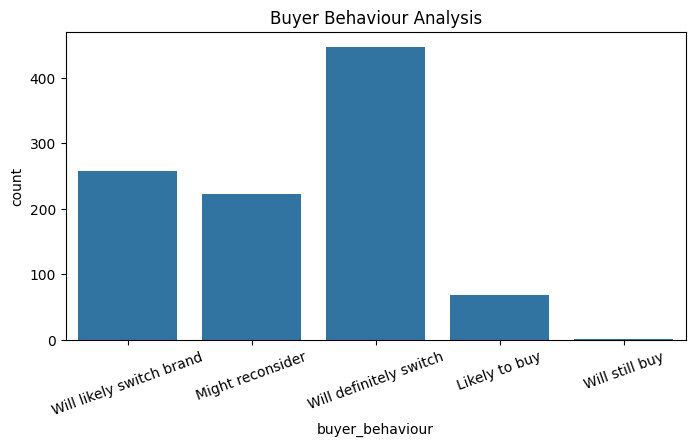

In [63]:
#  Buyer Behaviour Count Plot

plt.figure(figsize=(8,4))
sns.countplot(x='buyer_behaviour', data=df)
plt.xticks(rotation=20)
plt.title("Buyer Behaviour Analysis")
plt.show()

1) The chart shows that most customers “Will definitely switch” brands, indicating high price sensitivity.
2) A moderate number of buyers “Will likely switch brand” or “Might reconsider” after price changes.
3) Only a few customers are “Likely to buy” or “Will still buy”, showing fewer loyal buyers.
4) Overall, the analysis indicates that price increase strongly affects customer buying behaviour.

## Feature Engineering & Preprocessing

### Encoding  using Label encoding

Encoding means converting categorical/text data into numbers because ML models work with numerical values.

In [64]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

In [65]:
for i in ['buyer_behaviour','brand','model','segment','speedometer_type','price_sensitivity']:
    df[i]=le.fit_transform(df[i])

### Scaling the dataset 

#### Define X and Y  :

1) x : to decide first "Dependent Variable" and then "df.

drop" to the categorical values in axis 1.

2) y : to add dropped values. 

3) Using  the "StandardScaler" to "fit_transform" method  

by the x Variable.

4) create x1 Variable and convert on "pd.DataFrame" 

then  include numerical column names. 

5) Add "x1,y" in axis=1 using "pd.concat"

6) checking "max,min"  using  "describe()"

In [66]:
x=df.drop('buyer_behaviour',axis=1)

In [67]:
y=df['buyer_behaviour']

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scale=StandardScaler()

In [70]:
x_scale=scale.fit_transform(x)
print(x_scale[:5])

[[-0.58215412 -0.15270469 -0.36628439 -0.10049522 -1.54248177 -0.19674919
   0.05701268  0.06343023 -1.06728629 -0.5033866  -0.39843262 -0.50838886
  -0.50492508 -0.53302582 -0.07632349  0.3315228  -1.50370448]
 [-1.44015577  0.50835458  0.16414861 -0.10049522  0.82419528 -0.19674919
   0.74807544 -0.63432862  0.48025304 -0.18689608 -0.39843262 -0.21720383
  -0.19410962 -0.17325505  0.06741189 -0.95144108  0.11231323]
 [-1.01115494  1.21663237 -1.07624855 -1.40562797 -1.54248177 -1.7582507
  -1.39421913  1.40628689 -1.51865193 -1.07086805 -0.39843262 -1.03057548
  -1.06224936 -1.07666628 -1.94488344 -1.39554396  0.11231323]
 [ 0.27584753  1.40550645  0.95571785  1.20463752  1.41586455  1.36475232
   0.57530975 -0.90421648  1.25402271  0.14049008 -0.39843262  0.08408063
   0.12742362  0.16314557 -0.50752963  0.18348851 -1.50370448]
 [ 0.27584753  1.12219533  1.48615085  1.20463752  0.23252602  1.36475232
   1.02450055 -1.27942643  0.48025304  0.41339802  2.50983467  0.56440051
   0.4489

In [71]:
x1=pd.DataFrame(x_scale,columns=['brand', 'model', 'cc', 'segment', 'year', 'speedometer_type',
       'top_speed_kmh', 'mileage_kmpl', 'fuel_tank_liters',
       'factory_price_inr', 'gst_rate_pct', 'gst_amount_inr',
       'ex_showroom_inr', 'on_road_price_inr', 'overall_score',
       'price_increase_scenario_pct', 'price_sensitivity'])

In [72]:
x2=pd.concat([x1,y],axis=1)
x2

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,-0.582154,-0.152705,-0.366284,-0.100495,-1.542482,-0.196749,0.057013,0.063430,-1.067286,-0.503387,-0.398433,-0.508389,-0.504925,-0.533026,-0.076323,0.331523,-1.503704,3
1,-1.440156,0.508355,0.164149,-0.100495,0.824195,-0.196749,0.748075,-0.634329,0.480253,-0.186896,-0.398433,-0.217204,-0.194110,-0.173255,0.067412,-0.951441,0.112313,1
2,-1.011155,1.216632,-1.076249,-1.405628,-1.542482,-1.758251,-1.394219,1.406287,-1.518652,-1.070868,-0.398433,-1.030575,-1.062249,-1.076666,-1.944883,-1.395544,0.112313,1
3,0.275848,1.405506,0.955718,1.204638,1.415865,1.364752,0.575310,-0.904216,1.254023,0.140490,-0.398433,0.084081,0.127424,0.163146,-0.507530,0.183489,-1.503704,3
4,0.275848,1.122195,1.486151,1.204638,0.232526,1.364752,1.024501,-1.279426,0.480253,0.413398,2.509835,0.564401,0.448957,0.440994,0.354883,1.269073,0.920322,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.562850,0.744447,0.751705,1.204638,-1.542482,-0.196749,0.298885,-0.607998,0.512493,3.130688,-0.398433,2.835579,3.064094,3.067971,0.354883,-0.235942,-1.503704,3
996,-1.011155,1.358288,-0.847754,-1.405628,-0.359143,1.364752,-0.634050,0.701945,-0.325757,-0.929001,-0.398433,-0.900017,-0.922918,-0.912258,-1.657413,1.367763,0.920322,2
997,-1.440156,0.319481,-0.929359,-1.405628,0.824195,1.364752,-0.841369,0.484719,-0.841603,-1.027216,-0.398433,-0.990407,-1.019378,-1.008548,-1.369942,-1.247510,0.112313,1
998,1.133849,0.980540,-0.031704,-0.100495,0.824195,-0.196749,1.024501,-0.871303,0.867138,-0.230562,-0.398433,-0.257326,-0.236981,-0.222955,-0.076323,-1.395544,0.112313,1


In [73]:
x2.describe()

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000
mean,-1.110223e-16,-7.460699e-17,7.283063e-17,1.865175e-17,1.722356e-14,1.882938e-16,2.078338e-16,-3.188561e-16,2.469136e-16,-7.815970e-17,-1.339373e-15,-8.171241e-17,0.000000,9.592327e-17,-8.455459e-16,7.371881e-17,4.973799e-17,1.901000
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,0.869457
min,-1.440156e+00,-1.663697e+00,-1.076249e+00,-1.405628e+00,-1.542482e+00,-1.758251e+00,-1.739751e+00,-1.542732e+00,-1.744335e+00,-1.310949e+00,-3.984326e-01,-1.251524e+00,-1.298040,-1.316250e+00,-2.951031e+00,-1.716285e+00,-1.503704e+00,0.000000
25%,-1.011155e+00,-9.082010e-01,-8.477543e-01,-1.405628e+00,-9.508125e-01,-1.967492e-01,-7.031564e-01,-7.347137e-01,-7.771227e-01,-7.762107e-01,-3.984326e-01,-7.594516e-01,-0.772869,-7.720672e-01,-6.512650e-01,-8.527515e-01,-1.503704e+00,1.000000
50%,-1.531533e-01,1.256013e-02,-3.662844e-01,-1.004952e-01,2.325260e-01,-1.967492e-01,-8.119988e-02,-1.340487e-01,-6.783381e-02,-1.814413e-01,-3.984326e-01,-2.121771e-01,-0.188751,-1.953613e-01,6.741189e-02,1.078183e-02,1.123132e-01,2.000000
75%,1.133849e+00,8.388842e-01,8.027083e-01,1.204638e+00,8.241953e-01,1.364752e+00,6.530543e-01,6.690323e-01,7.381763e-01,4.024046e-01,-3.984326e-01,3.552045e-01,0.398047,3.916060e-01,6.423534e-01,8.249704e-01,9.203221e-01,3.000000
max,1.562850e+00,1.688818e+00,3.420191e+00,1.204638e+00,1.415865e+00,1.364752e+00,2.579392e+00,2.341020e+00,2.092273e+00,4.678679e+00,2.509835e+00,4.909728e+00,4.736067,4.803724e+00,2.510913e+00,1.737849e+00,9.203221e-01,4.000000


In [74]:
df=x2
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,-0.582154,-0.152705,-0.366284,-0.100495,-1.542482,-0.196749,0.057013,0.063430,-1.067286,-0.503387,-0.398433,-0.508389,-0.504925,-0.533026,-0.076323,0.331523,-1.503704,3
1,-1.440156,0.508355,0.164149,-0.100495,0.824195,-0.196749,0.748075,-0.634329,0.480253,-0.186896,-0.398433,-0.217204,-0.194110,-0.173255,0.067412,-0.951441,0.112313,1
2,-1.011155,1.216632,-1.076249,-1.405628,-1.542482,-1.758251,-1.394219,1.406287,-1.518652,-1.070868,-0.398433,-1.030575,-1.062249,-1.076666,-1.944883,-1.395544,0.112313,1
3,0.275848,1.405506,0.955718,1.204638,1.415865,1.364752,0.575310,-0.904216,1.254023,0.140490,-0.398433,0.084081,0.127424,0.163146,-0.507530,0.183489,-1.503704,3
4,0.275848,1.122195,1.486151,1.204638,0.232526,1.364752,1.024501,-1.279426,0.480253,0.413398,2.509835,0.564401,0.448957,0.440994,0.354883,1.269073,0.920322,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.562850,0.744447,0.751705,1.204638,-1.542482,-0.196749,0.298885,-0.607998,0.512493,3.130688,-0.398433,2.835579,3.064094,3.067971,0.354883,-0.235942,-1.503704,3
996,-1.011155,1.358288,-0.847754,-1.405628,-0.359143,1.364752,-0.634050,0.701945,-0.325757,-0.929001,-0.398433,-0.900017,-0.922918,-0.912258,-1.657413,1.367763,0.920322,2
997,-1.440156,0.319481,-0.929359,-1.405628,0.824195,1.364752,-0.841369,0.484719,-0.841603,-1.027216,-0.398433,-0.990407,-1.019378,-1.008548,-1.369942,-1.247510,0.112313,1
998,1.133849,0.980540,-0.031704,-0.100495,0.824195,-0.196749,1.024501,-0.871303,0.867138,-0.230562,-0.398433,-0.257326,-0.236981,-0.222955,-0.076323,-1.395544,0.112313,1


## Model selection & training

 To select the**Target and independent variables** in X 
 
 and Y.The target variable is **'buyer_behaviour'**, and the 
 
 remaining features are used as input variables. The 
 
 data is then split into training and testing sets. A 
 
 machine learning model is selected and trained using 
 
 the training data, and its performance is evaluated on 
 
 the test data.


In [75]:
x=df.drop('buyer_behaviour',axis=1)

In [76]:
y=df['buyer_behaviour']

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
lg=LogisticRegression(max_iter=100)

In [81]:
lg.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [82]:
y_pred=lg.predict(x_test)

In [83]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score

In [84]:
print(accuracy_score(y_test,y_pred))

print(lg.score(x_train,y_train))
print(lg.score(x_test,y_test))

1.0
0.99875
1.0


In [85]:
# confusion metrics

cm= confusion_matrix(y_test,y_pred)
cm

array([[14,  0,  0,  0],
       [ 0, 45,  0,  0],
       [ 0,  0, 89,  0],
       [ 0,  0,  0, 52]])

In [86]:
# classification report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        89
           3       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



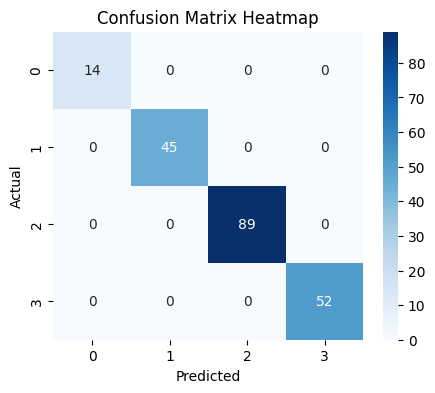

In [87]:
#heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()


The heatmap visualizes model prediction performance.
Diagonal values represent correct predictions.
Higher diagonal values indicate better accuracy.
Since Logistic Regression accuracy is 99.87%, most values appear correctly classified in the heatmap.

In [88]:
from sklearn.preprocessing import label_binarize

y_test_bin= label_binarize(y_test, classes=[0,1,2,3,4])

c:\python311\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


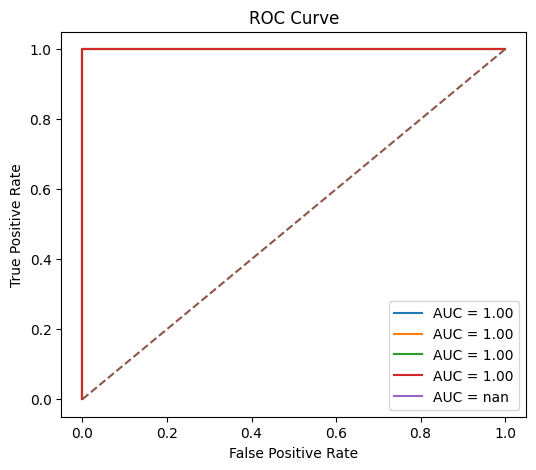

In [89]:
from sklearn.metrics import roc_auc_score,auc


# predict probability

y_prob=lg.predict_proba(x_test)


plt.figure(figsize=(6,5))

for i in range(5):
    fpr,tpr, _ = roc_curve(y_test_bin[:,i],y_prob[:,i])
    roc_auc =auc(fpr,tpr)

    plt.plot(fpr,tpr, label=f"AUC = {roc_auc:.2f}")

#plot roc  curve
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [90]:
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,-0.582154,-0.152705,-0.366284,-0.100495,-1.542482,-0.196749,0.057013,0.063430,-1.067286,-0.503387,-0.398433,-0.508389,-0.504925,-0.533026,-0.076323,0.331523,-1.503704,3
1,-1.440156,0.508355,0.164149,-0.100495,0.824195,-0.196749,0.748075,-0.634329,0.480253,-0.186896,-0.398433,-0.217204,-0.194110,-0.173255,0.067412,-0.951441,0.112313,1
2,-1.011155,1.216632,-1.076249,-1.405628,-1.542482,-1.758251,-1.394219,1.406287,-1.518652,-1.070868,-0.398433,-1.030575,-1.062249,-1.076666,-1.944883,-1.395544,0.112313,1
3,0.275848,1.405506,0.955718,1.204638,1.415865,1.364752,0.575310,-0.904216,1.254023,0.140490,-0.398433,0.084081,0.127424,0.163146,-0.507530,0.183489,-1.503704,3
4,0.275848,1.122195,1.486151,1.204638,0.232526,1.364752,1.024501,-1.279426,0.480253,0.413398,2.509835,0.564401,0.448957,0.440994,0.354883,1.269073,0.920322,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.562850,0.744447,0.751705,1.204638,-1.542482,-0.196749,0.298885,-0.607998,0.512493,3.130688,-0.398433,2.835579,3.064094,3.067971,0.354883,-0.235942,-1.503704,3
996,-1.011155,1.358288,-0.847754,-1.405628,-0.359143,1.364752,-0.634050,0.701945,-0.325757,-0.929001,-0.398433,-0.900017,-0.922918,-0.912258,-1.657413,1.367763,0.920322,2
997,-1.440156,0.319481,-0.929359,-1.405628,0.824195,1.364752,-0.841369,0.484719,-0.841603,-1.027216,-0.398433,-0.990407,-1.019378,-1.008548,-1.369942,-1.247510,0.112313,1
998,1.133849,0.980540,-0.031704,-0.100495,0.824195,-0.196749,1.024501,-0.871303,0.867138,-0.230562,-0.398433,-0.257326,-0.236981,-0.222955,-0.076323,-1.395544,0.112313,1


In [91]:
new_bike = {
    'brand' : 2,
    'model' : 32,
    'cc'    : 220,
    'segment': '1',
    'year': 2020,
    'speedometer_type' : 1,
    'top_speed_kmh': 145,
    'mileage_kmpl': 43.8,
    'fuel_tank_liters': 10.1 ,
    'factory_price_inr':100781,
    'gst_rate_pct':28.0,
    'gst_amount_inr':28219,
    'ex_showroom_inr':129000,
    'on_road_price_inr':147604,
    'overall_score':70,
    'price_increase_scenario_pct':9.3,
    'price_sensitivity':'0'

    }

new_data = pd.DataFrame([new_bike])

In [92]:
le = LabelEncoder()

for col in ['brand','model','segment','speedometer_type', 'price_sensitivity']:
    df[col] = le.fit_transform(df[col])

In [93]:
new_scaled=scale.transform(new_data)
prediction=lg.predict(new_scaled)
print(prediction)

[3]


c:\python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [94]:
print(accuracy_score(y_test,y_pred))

1.0


In [95]:
from sklearn.metrics import accuracy_score

y_true = [3] 
# the actual class is 3    # 
y_pred = [3]
# the model predicted 3

print(accuracy_score(y_true, y_pred))

1.0


In [96]:
df

,brand,model,cc,segment,year,speedometer_type,top_speed_kmh,mileage_kmpl,fuel_tank_liters,factory_price_inr,gst_rate_pct,gst_amount_inr,ex_showroom_inr,on_road_price_inr,overall_score,price_increase_scenario_pct,price_sensitivity,buyer_behaviour
0,2,32,-0.366284,1,-1.542482,1,0.057013,0.063430,-1.067286,-0.503387,-0.398433,-0.508389,-0.504925,-0.533026,-0.076323,0.331523,0,3
1,0,46,0.164149,1,0.824195,1,0.748075,-0.634329,0.480253,-0.186896,-0.398433,-0.217204,-0.194110,-0.173255,0.067412,-0.951441,2,1
2,1,61,-1.076249,0,-1.542482,0,-1.394219,1.406287,-1.518652,-1.070868,-0.398433,-1.030575,-1.062249,-1.076666,-1.944883,-1.395544,2,1
3,4,65,0.955718,2,1.415865,2,0.575310,-0.904216,1.254023,0.140490,-0.398433,0.084081,0.127424,0.163146,-0.507530,0.183489,0,3
4,4,59,1.486151,2,0.232526,2,1.024501,-1.279426,0.480253,0.413398,2.509835,0.564401,0.448957,0.440994,0.354883,1.269073,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7,51,0.751705,2,-1.542482,1,0.298885,-0.607998,0.512493,3.130688,-0.398433,2.835579,3.064094,3.067971,0.354883,-0.235942,0,3
996,1,64,-0.847754,0,-0.359143,2,-0.634050,0.701945,-0.325757,-0.929001,-0.398433,-0.900017,-0.922918,-0.912258,-1.657413,1.367763,3,2
997,0,42,-0.929359,0,0.824195,2,-0.841369,0.484719,-0.841603,-1.027216,-0.398433,-0.990407,-1.019378,-1.008548,-1.369942,-1.247510,2,1
998,6,56,-0.031704,1,0.824195,1,1.024501,-0.871303,0.867138,-0.230562,-0.398433,-0.257326,-0.236981,-0.222955,-0.076323,-1.395544,2,1


#### Project Title

Indian Bike Market Analysis and Prediction Using Machine Learning

#### Objective 

The main objective of this project is to analyze Indian motorcycle data and build machine learning models to predict customer-related outcomes such as buyer behaviour or price sensitivity based on bike specifications and pricing details.

#### Dataset Used

1) Dataset Name: indian_bikes_dataset_1000.csv
2) Total Records: 1000
3) Dataset Type: Structured CSV dataset

#### Feature Used

1) Brand
2) Model
3) Engine Capacity (CC)
4) Segment
5) Year
6) Speedometer Type
7) Top Speed
8) Mileage
9) Fuel Tank Capacity
10) Factory Price
11) GST Rate
12) GST Amount
13) Ex-Showroom Price
14) On-Road Price
15) Overall Score
16) Price Increase Scenario
17) Buyer Behaviour
18) Price Sensitivity

#### Technologies Used

1) Python
2) Pandas
3) NumPy
4) Matplotlib
5) Seaborn
6) Scikit-learn

#### Machine Learning Algorithms Used

a) Logistic Regression


#### Data Preprocessing

1) Checked missing values
2) Removed duplicates
3) Encoded categorical features
4) Feature scaling using StandardScaler
5) Train-test splitting

#### Exploratory Data Analysis (EDA)

1) Histograms
2) Count plots
3) Box plots
4) Correlation heatmaps
5) Pair plots
6) Bar charts

#### Model Performance

| Model        |  Accuracy    |        
|--------------|--------------|
| Logistic Regression | 100%  |














# Conclusion 

This project successfully analyzed the Indian bike dataset and applied multiple machine learning algorithms to predict customer-related behaviour.

 Exploratory Data Analysis helped identify important relationships between bike specifications, pricing, mileage, and customer preferences.

The Logistic Regression model achieved an accuracy of 100%, indicating that the selected features effectively captured patterns related to buyer behaviour. The model was also tested with modified input values to observe how changes in bike characteristics influence customer responses.